In [ ]:
CÂU 1 - TRAIN CNN 10 EPOCH
Phần A - Giữ nguyên phần chuẩn bị dữ liệu

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
np.random.seed(42)

device = torch.device(
    'cuda'
    if torch.cuda.is_available()
    else 'cpu'
)

print("Device:", device)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.1307,),
        (0.3081,)
    )
])

train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

print(
    f"Train: {len(train_dataset)}"
)

print(
    f"Test : {len(test_dataset)}"
)

Device: cpu


100%|██████████| 9.91M/9.91M [00:00<00:00, 142MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 15.0MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 148MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.49MB/s]


Train: 60000
Test : 10000


Phần B - Xây dựng CNN

In [3]:
class MNIST_CNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.conv1 = nn.Conv2d(
            1,
            16,
            kernel_size=3
        )

        self.conv2 = nn.Conv2d(
            16,
            32,
            kernel_size=3
        )

        self.pool = nn.MaxPool2d(
            2,
            2
        )

        self.fc1 = nn.Linear(
            32*5*5,
            10
        )

    def forward(self,x):

        x = self.pool(
            torch.relu(
                self.conv1(x)
            )
        )

        x = self.pool(
            torch.relu(
                self.conv2(x)
            )
        )

        x = x.view(
            x.size(0),
            -1
        )

        x = self.fc1(x)

        return x

model = MNIST_CNN().to(device)

print(model)

n_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(
    f"Total Parameters: {n_params:,}"
)

MNIST_CNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=800, out_features=10, bias=True)
)
Total Parameters: 12,810


Phần C - Hàm đánh giá

In [4]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(
    model.parameters(),
    lr=0.01,
    momentum=0.9
)

def evaluate(model, loader):

    model.eval()

    loss_sum = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            loss_sum += (
                loss.item()
                * images.size(0)
            )

            correct += (
                outputs.argmax(1)
                == labels
            ).sum().item()

            total += labels.size(0)

    return (
        loss_sum / total,
        correct / total
    )

Phần D - Train 10 Epoch

In [5]:
num_epochs = 10

loss_history = []
acc_history = []

test_loss_history = []
test_acc_history = []

for epoch in range(num_epochs):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += (
            loss.item()
            * images.size(0)
        )

        correct += (
            outputs.argmax(1)
            == labels
        ).sum().item()

        total += labels.size(0)

    train_loss = (
        running_loss / total
    )

    train_acc = (
        correct / total
    )

    test_loss, test_acc = evaluate(
        model,
        test_loader
    )

    loss_history.append(
        train_loss
    )

    acc_history.append(
        train_acc
    )

    test_loss_history.append(
        test_loss
    )

    test_acc_history.append(
        test_acc
    )

    print(
        f"Epoch {epoch+1}/{num_epochs} "
        f"train_acc={train_acc*100:.2f}% "
        f"test_acc={test_acc*100:.2f}%"
    )

Epoch 1/10 train_acc=94.30% test_acc=97.93%
Epoch 2/10 train_acc=98.06% test_acc=98.13%
Epoch 3/10 train_acc=98.50% test_acc=98.70%
Epoch 4/10 train_acc=98.69% test_acc=98.52%
Epoch 5/10 train_acc=98.80% test_acc=98.62%
Epoch 6/10 train_acc=99.06% test_acc=98.93%
Epoch 7/10 train_acc=99.10% test_acc=98.90%
Epoch 8/10 train_acc=99.18% test_acc=98.85%
Epoch 9/10 train_acc=99.28% test_acc=98.86%
Epoch 10/10 train_acc=99.31% test_acc=98.95%


Phần E - Biểu đồ

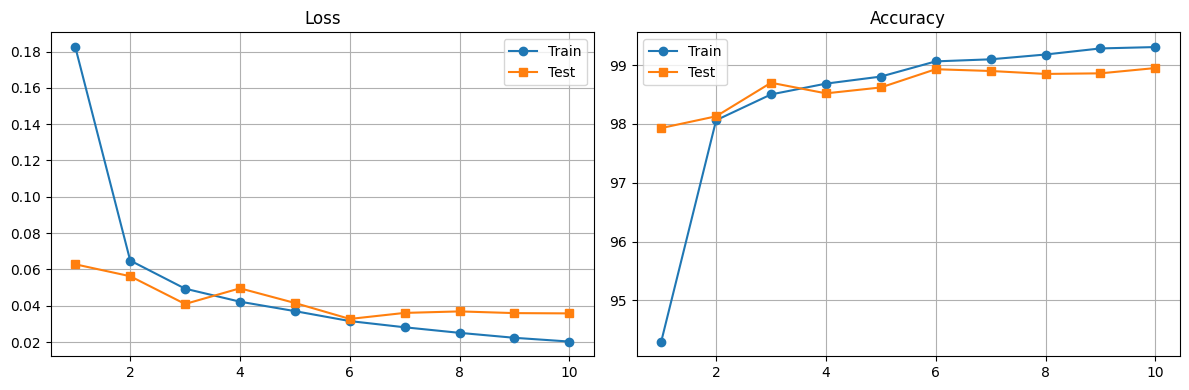

In [6]:
epochs = range(
    1,
    num_epochs+1
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12,4)
)

axes[0].plot(
    epochs,
    loss_history,
    'o-',
    label='Train'
)

axes[0].plot(
    epochs,
    test_loss_history,
    's-',
    label='Test'
)

axes[0].set_title("Loss")
axes[0].legend()
axes[0].grid()

axes[1].plot(
    epochs,
    [a*100 for a in acc_history],
    'o-',
    label='Train'
)

axes[1].plot(
    epochs,
    [a*100 for a in test_acc_history],
    's-',
    label='Test'
)

axes[1].set_title("Accuracy")
axes[1].legend()
axes[1].grid()

plt.tight_layout()
plt.show()

Phần F - Accuracy cuối cùng

In [7]:
final_test_loss, final_test_acc = evaluate(
    model,
    test_loader
)

print(
    f"Final Test Accuracy = {final_test_acc*100:.2f}%"
)

Final Test Accuracy = 98.95%


CÂU 2 - THÊM TẦNG TÍCH CHẬP THỨ BA (CONV3)
Phần A - Chuẩn bị dữ liệu

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
np.random.seed(42)

device = torch.device(
    'cuda'
    if torch.cuda.is_available()
    else 'cpu'
)

print("Device:", device)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.1307,),
        (0.3081,)
    )
])

train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=transform
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

Device: cpu


Phần B - Xây dựng CNN có 3 tầng Convolution

In [9]:
class MNIST_CNN_3Conv(nn.Module):

    def __init__(self):

        super().__init__()

        self.conv1 = nn.Conv2d(
            1,
            16,
            kernel_size=3
        )

        self.conv2 = nn.Conv2d(
            16,
            32,
            kernel_size=3
        )

        self.conv3 = nn.Conv2d(
            32,
            64,
            kernel_size=3,
            padding=1
        )

        self.pool = nn.MaxPool2d(
            kernel_size=2,
            stride=2
        )

        self.fc1 = nn.Linear(
            64 * 2 * 2,
            10
        )

    def forward(self,x):

        x = self.pool(
            torch.relu(
                self.conv1(x)
            )
        )

        x = self.pool(
            torch.relu(
                self.conv2(x)
            )
        )

        x = self.pool(
            torch.relu(
                self.conv3(x)
            )
        )

        # Debug nếu cần
        # print(x.shape)

        x = x.view(
            x.size(0),
            -1
        )

        x = self.fc1(x)

        return x

model = MNIST_CNN_3Conv().to(device)

print(model)

n_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(
    f"Tổng tham số: {n_params:,}"
)

MNIST_CNN_3Conv(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
  (conv3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=256, out_features=10, bias=True)
)
Tổng tham số: 25,866


Phần C - Hàm đánh giá

In [11]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(
    model.parameters(),
    lr=0.01,
    momentum=0.9
)

def evaluate(model, loader):

    model.eval()

    loss_sum = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            loss_sum += (
                loss.item()
                * images.size(0)
            )

            correct += (
                outputs.argmax(1)
                == labels
            ).sum().item()

            total += labels.size(0)

    return (
        loss_sum / total,
        correct / total
    )

Phần D - Huấn luyện

In [12]:
num_epochs = 5

loss_history = []
acc_history = []

test_loss_history = []
test_acc_history = []

for epoch in range(num_epochs):

    model.train()

    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        running_loss += (
            loss.item()
            * images.size(0)
        )

        correct += (
            outputs.argmax(1)
            == labels
        ).sum().item()

        total += labels.size(0)

    train_loss = running_loss / total
    train_acc = correct / total

    test_loss, test_acc = evaluate(
        model,
        test_loader
    )

    loss_history.append(train_loss)
    acc_history.append(train_acc)

    test_loss_history.append(test_loss)
    test_acc_history.append(test_acc)

    print(
        f"Epoch {epoch+1}/{num_epochs} "
        f"train_acc={train_acc*100:.2f}% "
        f"test_acc={test_acc*100:.2f}%"
    )

Epoch 1/5 train_acc=91.98% test_acc=97.77%
Epoch 2/5 train_acc=98.03% test_acc=98.62%
Epoch 3/5 train_acc=98.67% test_acc=98.89%
Epoch 4/5 train_acc=98.89% test_acc=98.93%
Epoch 5/5 train_acc=99.10% test_acc=98.89%


Phần E - Vẽ biểu đồ

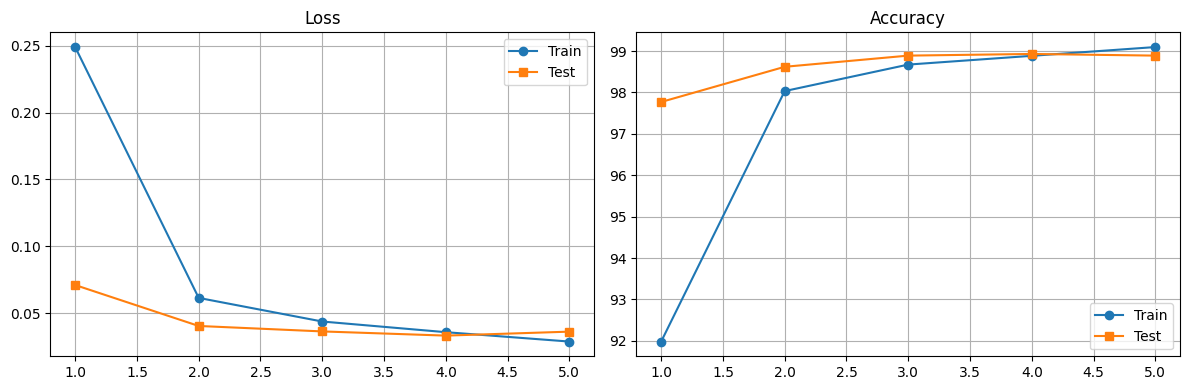

In [13]:
epochs = range(
    1,
    num_epochs+1
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12,4)
)

axes[0].plot(
    epochs,
    loss_history,
    'o-',
    label='Train'
)

axes[0].plot(
    epochs,
    test_loss_history,
    's-',
    label='Test'
)

axes[0].set_title("Loss")
axes[0].legend()
axes[0].grid()

axes[1].plot(
    epochs,
    [a*100 for a in acc_history],
    'o-',
    label='Train'
)

axes[1].plot(
    epochs,
    [a*100 for a in test_acc_history],
    's-',
    label='Test'
)

axes[1].set_title("Accuracy")
axes[1].legend()
axes[1].grid()

plt.tight_layout()
plt.show()

Phần F - Kết quả cuối cùng

In [14]:
test_loss, test_acc = evaluate(
    model,
    test_loader
)

print(
    f"Final Test Accuracy: {test_acc*100:.2f}%"
)

Final Test Accuracy: 98.89%


BAI 3


Training với lr = 0.001
Epoch 1/5 Loss = 0.4828
Epoch 2/5 Loss = 0.1545
Epoch 3/5 Loss = 0.1127
Epoch 4/5 Loss = 0.0922
Epoch 5/5 Loss = 0.0816

Training với lr = 0.01
Epoch 1/5 Loss = 0.1658
Epoch 2/5 Loss = 0.0603
Epoch 3/5 Loss = 0.0462
Epoch 4/5 Loss = 0.0379
Epoch 5/5 Loss = 0.0324

Training với lr = 0.1
Epoch 1/5 Loss = 0.1734
Epoch 2/5 Loss = 0.1158
Epoch 3/5 Loss = 0.0855
Epoch 4/5 Loss = 0.0768
Epoch 5/5 Loss = 0.0784


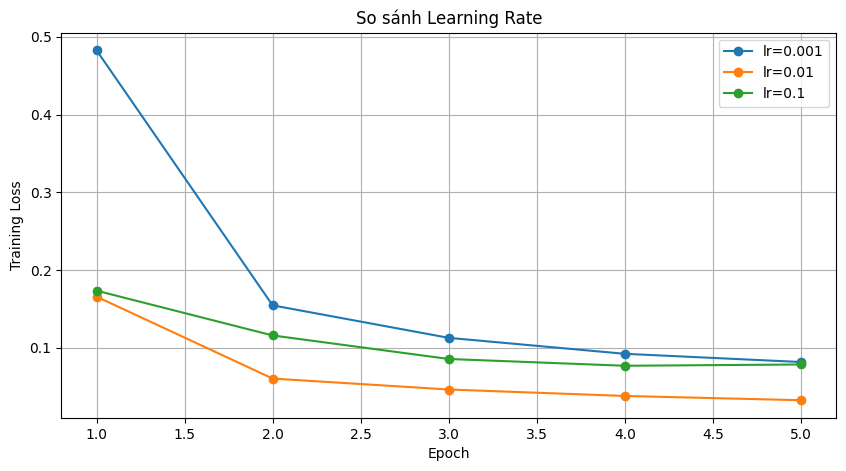

In [15]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
np.random.seed(42)

device = torch.device(
    'cuda'
    if torch.cuda.is_available()
    else 'cpu'
)

# ==========================
# DATASET
# ==========================

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(
        (0.1307,),
        (0.3081,)
    )
])

train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=transform
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

# ==========================
# CNN GỐC
# ==========================

class MNIST_CNN(nn.Module):

    def __init__(self):

        super().__init__()

        self.conv1 = nn.Conv2d(
            1,
            16,
            kernel_size=3
        )

        self.conv2 = nn.Conv2d(
            16,
            32,
            kernel_size=3
        )

        self.pool = nn.MaxPool2d(
            2,
            2
        )

        self.fc1 = nn.Linear(
            32 * 5 * 5,
            10
        )

    def forward(self,x):

        x = self.pool(
            torch.relu(
                self.conv1(x)
            )
        )

        x = self.pool(
            torch.relu(
                self.conv2(x)
            )
        )

        x = x.view(
            x.size(0),
            -1
        )

        x = self.fc1(x)

        return x

# ==========================
# THỬ 3 LEARNING RATE
# ==========================

learning_rates = [
    0.001,
    0.01,
    0.1
]

all_losses = {}

criterion = nn.CrossEntropyLoss()

for lr in learning_rates:

    print(f"\nTraining với lr = {lr}")

    model = MNIST_CNN().to(device)

    optimizer = optim.SGD(
        model.parameters(),
        lr=lr,
        momentum=0.9
    )

    epoch_losses = []

    for epoch in range(5):

        model.train()

        running_loss = 0
        total = 0

        for images, labels in train_loader:

            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

            loss.backward()

            optimizer.step()

            running_loss += (
                loss.item()
                * images.size(0)
            )

            total += labels.size(0)

        avg_loss = (
            running_loss / total
        )

        epoch_losses.append(
            avg_loss
        )

        print(
            f"Epoch {epoch+1}/5 "
            f"Loss = {avg_loss:.4f}"
        )

    all_losses[lr] = epoch_losses

# ==========================
# VẼ ĐỒ THỊ
# ==========================

plt.figure(figsize=(10,5))

for lr in learning_rates:

    plt.plot(
        range(1,6),
        all_losses[lr],
        marker='o',
        label=f"lr={lr}"
    )

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title(
    "So sánh Learning Rate"
)

plt.legend()
plt.grid()

plt.show()

Câu 4: Vẽ thêm feature maps từ conv2

Conv1 shape: torch.Size([1, 16, 26, 26])
Conv2 shape: torch.Size([1, 32, 11, 11])


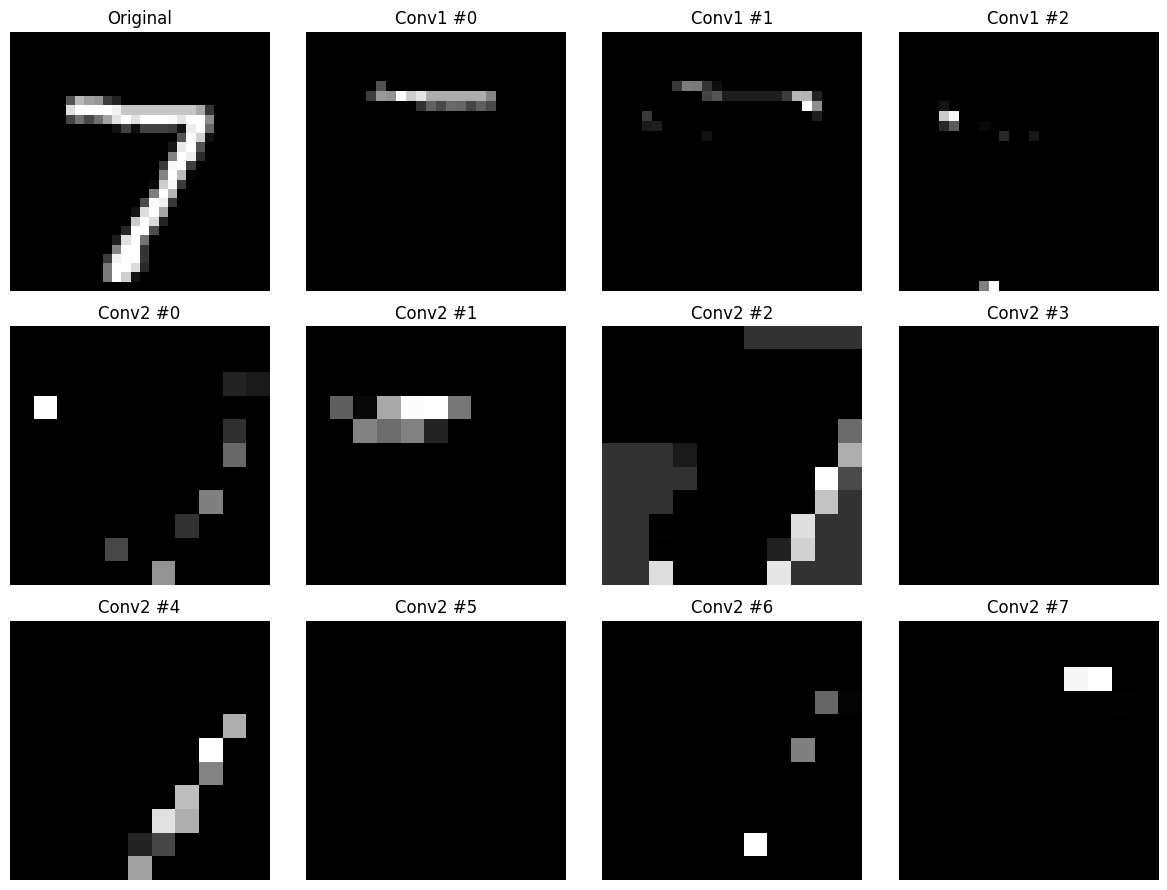

In [16]:

model.eval()

images, labels = next(iter(test_loader))

img = images[0].unsqueeze(0).to(device)

with torch.no_grad():

    # Feature map Conv1
    h1 = torch.relu(
        model.conv1(img)
    )

    h1_pool = model.pool(h1)

    # Feature map Conv2
    h2 = torch.relu(
        model.conv2(h1_pool)
    )

print("Conv1 shape:", h1.shape)
print("Conv2 shape:", h2.shape)

fig, axes = plt.subplots(
    3,
    4,
    figsize=(12,9)
)

# Ảnh gốc

axes[0,0].imshow(
    img.cpu().squeeze() * 0.3081 + 0.1307,
    cmap='gray'
)

axes[0,0].set_title(
    "Original"
)

axes[0,0].axis('off')

# Conv1 feature maps

for i in range(3):

    axes[0,i+1].imshow(
        h1[0,i].cpu(),
        cmap='gray'
    )

    axes[0,i+1].set_title(
        f"Conv1 #{i}"
    )

    axes[0,i+1].axis('off')

# Conv2 feature maps

for i in range(4):

    axes[1,i].imshow(
        h2[0,i].cpu(),
        cmap='gray'
    )

    axes[1,i].set_title(
        f"Conv2 #{i}"
    )

    axes[1,i].axis('off')

# Thêm 4 feature maps khác của Conv2

for i in range(4):

    axes[2,i].imshow(
        h2[0,i+4].cpu(),
        cmap='gray'
    )

    axes[2,i].set_title(
        f"Conv2 #{i+4}"
    )

    axes[2,i].axis('off')

plt.tight_layout()

plt.show()

Câu 5: Thêm Dropout và Data Augmentation


100%|██████████| 9.91M/9.91M [00:00<00:00, 20.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 511kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.71MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.69MB/s]


Epoch 1/10 Train Acc = 86.19% Test Acc = 97.54%
Epoch 2/10 Train Acc = 94.01% Test Acc = 98.29%
Epoch 3/10 Train Acc = 95.06% Test Acc = 98.73%
Epoch 4/10 Train Acc = 95.62% Test Acc = 98.78%
Epoch 5/10 Train Acc = 95.97% Test Acc = 98.67%
Epoch 6/10 Train Acc = 96.19% Test Acc = 98.88%
Epoch 7/10 Train Acc = 96.38% Test Acc = 98.96%
Epoch 8/10 Train Acc = 96.62% Test Acc = 99.00%
Epoch 9/10 Train Acc = 96.67% Test Acc = 99.01%
Epoch 10/10 Train Acc = 96.67% Test Acc = 98.99%

Final Test Accuracy: 98.99%


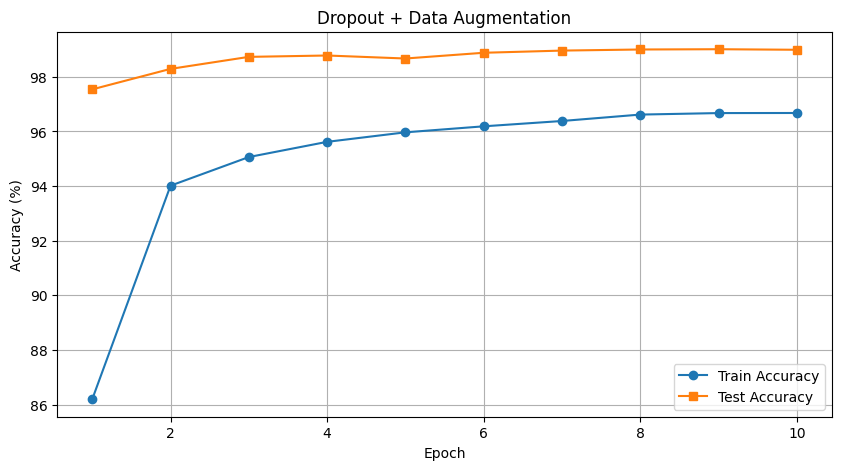

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
np.random.seed(42)

device = torch.device(
    'cuda'
    if torch.cuda.is_available()
    else 'cpu'
)

# ==================================
# DATA AUGMENTATION CHỈ CHO TRAIN
# ==================================

train_transform = transforms.Compose([

    transforms.RandomAffine(
        degrees=10,
        translate=(0.1,0.1)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        (0.1307,),
        (0.3081,)
    )
])

test_transform = transforms.Compose([

    transforms.ToTensor(),

    transforms.Normalize(
        (0.1307,),
        (0.3081,)
    )
])

# ==================================
# DATASET
# ==================================

train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    download=True,
    transform=train_transform
)

test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    download=True,
    transform=test_transform
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=64,
    shuffle=True
)

test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False
)

# ==================================
# CNN + DROPOUT
# ==================================

class MNIST_CNN_Dropout(nn.Module):

    def __init__(self):

        super().__init__()

        self.conv1 = nn.Conv2d(
            1,
            16,
            kernel_size=3
        )

        self.conv2 = nn.Conv2d(
            16,
            32,
            kernel_size=3
        )

        self.pool = nn.MaxPool2d(
            2,
            2
        )

        self.dropout = nn.Dropout(
            p=0.25
        )

        self.fc1 = nn.Linear(
            32*5*5,
            10
        )

    def forward(self,x):

        x = self.pool(
            torch.relu(
                self.conv1(x)
            )
        )

        x = self.pool(
            torch.relu(
                self.conv2(x)
            )
        )

        x = self.dropout(x)

        x = x.view(
            x.size(0),
            -1
        )

        x = self.fc1(x)

        return x

model = MNIST_CNN_Dropout().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.SGD(
    model.parameters(),
    lr=0.01,
    momentum=0.9
)

# ==================================
# EVALUATE
# ==================================

def evaluate(model, loader):

    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            preds = outputs.argmax(1)

            correct += (
                preds == labels
            ).sum().item()

            total += labels.size(0)

    return correct / total

# ==================================
# TRAIN 10 EPOCH
# ==================================

num_epochs = 10

train_accs = []
test_accs = []

for epoch in range(num_epochs):

    model.train()

    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(
            outputs,
            labels
        )

        loss.backward()

        optimizer.step()

        preds = outputs.argmax(1)

        correct += (
            preds == labels
        ).sum().item()

        total += labels.size(0)

    train_acc = correct / total

    test_acc = evaluate(
        model,
        test_loader
    )

    train_accs.append(
        train_acc
    )

    test_accs.append(
        test_acc
    )

    print(
        f"Epoch {epoch+1}/10 "
        f"Train Acc = {train_acc*100:.2f}% "
        f"Test Acc = {test_acc*100:.2f}%"
    )

# ==================================
# KẾT QUẢ CUỐI
# ==================================

print(
    "\nFinal Test Accuracy:",
    f"{test_accs[-1]*100:.2f}%"
)

# ==================================
# BIỂU ĐỒ
# ==================================

plt.figure(figsize=(10,5))

plt.plot(
    range(1,11),
    [a*100 for a in train_accs],
    marker='o',
    label='Train Accuracy'
)

plt.plot(
    range(1,11),
    [a*100 for a in test_accs],
    marker='s',
    label='Test Accuracy'
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")

plt.title(
    "Dropout + Data Augmentation"
)

plt.legend()
plt.grid()

plt.show()